In [ ]:
import numpy as np
from omegaconf import DictConfig

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

from src.handlers.rome import ModelHandler

cfg = DictConfig({
    "model": {
        "name": "gpt2-large",
        "models_dir": "../../models",
        "second_moment_dir": "../data/second_moment_stats",
        "new_weights_dir": "../data/new_weights",
        "device": "cuda",
        "save_to_local": True, # Keep this True until you specifically do not want the model cached locally
        "layer_name_template": "transformer.h.{}.mlp.c_proj",
        "restore_layer_name_template": "transformer.h.{}",
        "corrupt_layer_name_template": "transformer.wte",
        "layer": 12,
        "corruption_noise_multiplier": 0.1380615234375,
        "lr": 0.5,
        "kl_factor": 0.0625,
        "weight_decay": 0.5,
        "epochs": 20,
        "epsilon": 0.0,
        "optimize_pcs": False,
        "dtype": "bf16"

    },
    "generation": None,
    "dataset_sm": None,
    "dataset_facts": {
        "name": "azhx/counterfact",
        "concat_splits": ["train", "test"],
        "datasets_dir": "../../datasets",
        "save_to_local": True
    },})

handler = ModelHandler(cfg)

layer=12
U = handler.model.transformer.h[layer].mlp.c_fc.weight.cpu().detach().float().T
D = handler.model.transformer.h[layer].mlp.c_proj.weight.cpu().detach().float().T

In [ ]:
import numpy as np
from scipy.linalg import null_space
from torch.nn import GELU
import torch

def analyze_null_space(M1, a, function_type='relu'):
    # 1. Check Linear Null Space of M1
    # If this isn't empty, some 'a' vectors are lost immediately
    ns = null_space(M1)
    
    # 2. Forward pass to the intermediate "Z" space
    z = M1 @ a
    
    # 3. Identify "Dead" Dimensions
    # For ReLU, any index where z <= 0 is a point of inconsistency
    if function_type == 'relu':
        dead_indices = np.where(z <= 0)[0]
        alive_indices = np.where(z > 0)[0]
    
    return z, dead_indices, alive_indices

def analyze(U, D, x):
    h1 = U @ x
    g = GELU()
    h2 = g(h1).float()
    y = D @ h2

    z, dead, alive = analyze_null_space(D, h2)

    # print(f"Intermediate Vector (z): {z}")
    # print(f"Indices lost to the Null Space of ReLU: {dead}")
    print(f"Percentage of Information Lost: {(len(dead)/U.shape[1])*100}%")

# Example Setup
layer=12
U = handler.model.transformer.h[layer].mlp.c_fc.weight.cpu().detach().float().T
D = handler.model.transformer.h[layer].mlp.c_proj.weight.cpu().detach().float().T

x = torch.ones(U.shape[1])
analyze(U, D, x)

x = torch.ones(U.shape[1]) * -1.0
analyze(U, D, x)


In [ ]:
x = torch.ones(U.shape[1])
y = D @ (U @ x)
z = U.T @ (D.T @ y)

print(x)
print(z)

In [ ]:
import matplotlib.pyplot as plt
x = torch.ones(U.shape[1]) * -0.0547
y = D @ (U @ x)
z_neg = U.T @ (D.T @ y)
fig = plt.figure(figsize=(16,10))
ax = plt.axes()
ax.plot(x, color="b")
ax.plot(z_neg, color="r")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
x = torch.ones(U.shape[1]) * 0.1
y = D @ (U @ x)
z_orig = U.T @ (D.T @ y)
fig = plt.figure(figsize=(16,10))
ax = plt.axes()
ax.plot(x, color="b")
ax.plot(z_orig, color="r")

plt.show()

In [ ]:
from src.rome.rome import batch_intervention_generator
for new_W, _, prompt_dict, success in batch_intervention_generator(handler):
    new_W = new_W.cpu().detach().float().T

    import matplotlib.pyplot as plt
    x = torch.ones(U.shape[1]) * 0.1
    y = new_W @ (U @ x)
    z_rome = U.T @ (new_W.T @ y)
    fig = plt.figure(figsize=(16,10))
    ax = plt.axes()
    ax.plot(x, color="b")
    ax.plot(z_rome, color="r")

    plt.show()
    break

In [ ]:
from scipy import signal

correlation = signal.correlate(z_orig, z_rome, mode='same')
print(correlation, np.argmax(correlation))

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16,10))
ax = plt.axes()
ax.plot(correlation, color="r")

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16,10))
ax = plt.axes()
ax.plot(x, color="b")
ax.plot(z_orig @ z_rome, color="r")

plt.show()

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_i

Mother Tongue: Danielle Darrieux tensor(-7.1527, device='cuda:0')
Capital: Australia tensor(-7.1554, device='cuda:0')
Company: Nintendo tensor(-7.1536, device='cuda:0')
Element: Silver tensor(-7.1547, device='cuda:0')
Invention: Telephone tensor(-7.1545, device='cuda:0')
Language: Brazil tensor(-7.1550, device='cuda:0')
Author: Hamlet tensor(-7.1549, device='cuda:0')
Biology: Whale tensor(-7.1556, device='cuda:0')
Planet: Distance tensor(-7.1561, device='cuda:0')
Mythology: Zeus tensor(-7.1535, device='cuda:0')
Currency: Japan tensor(-7.1557, device='cuda:0')


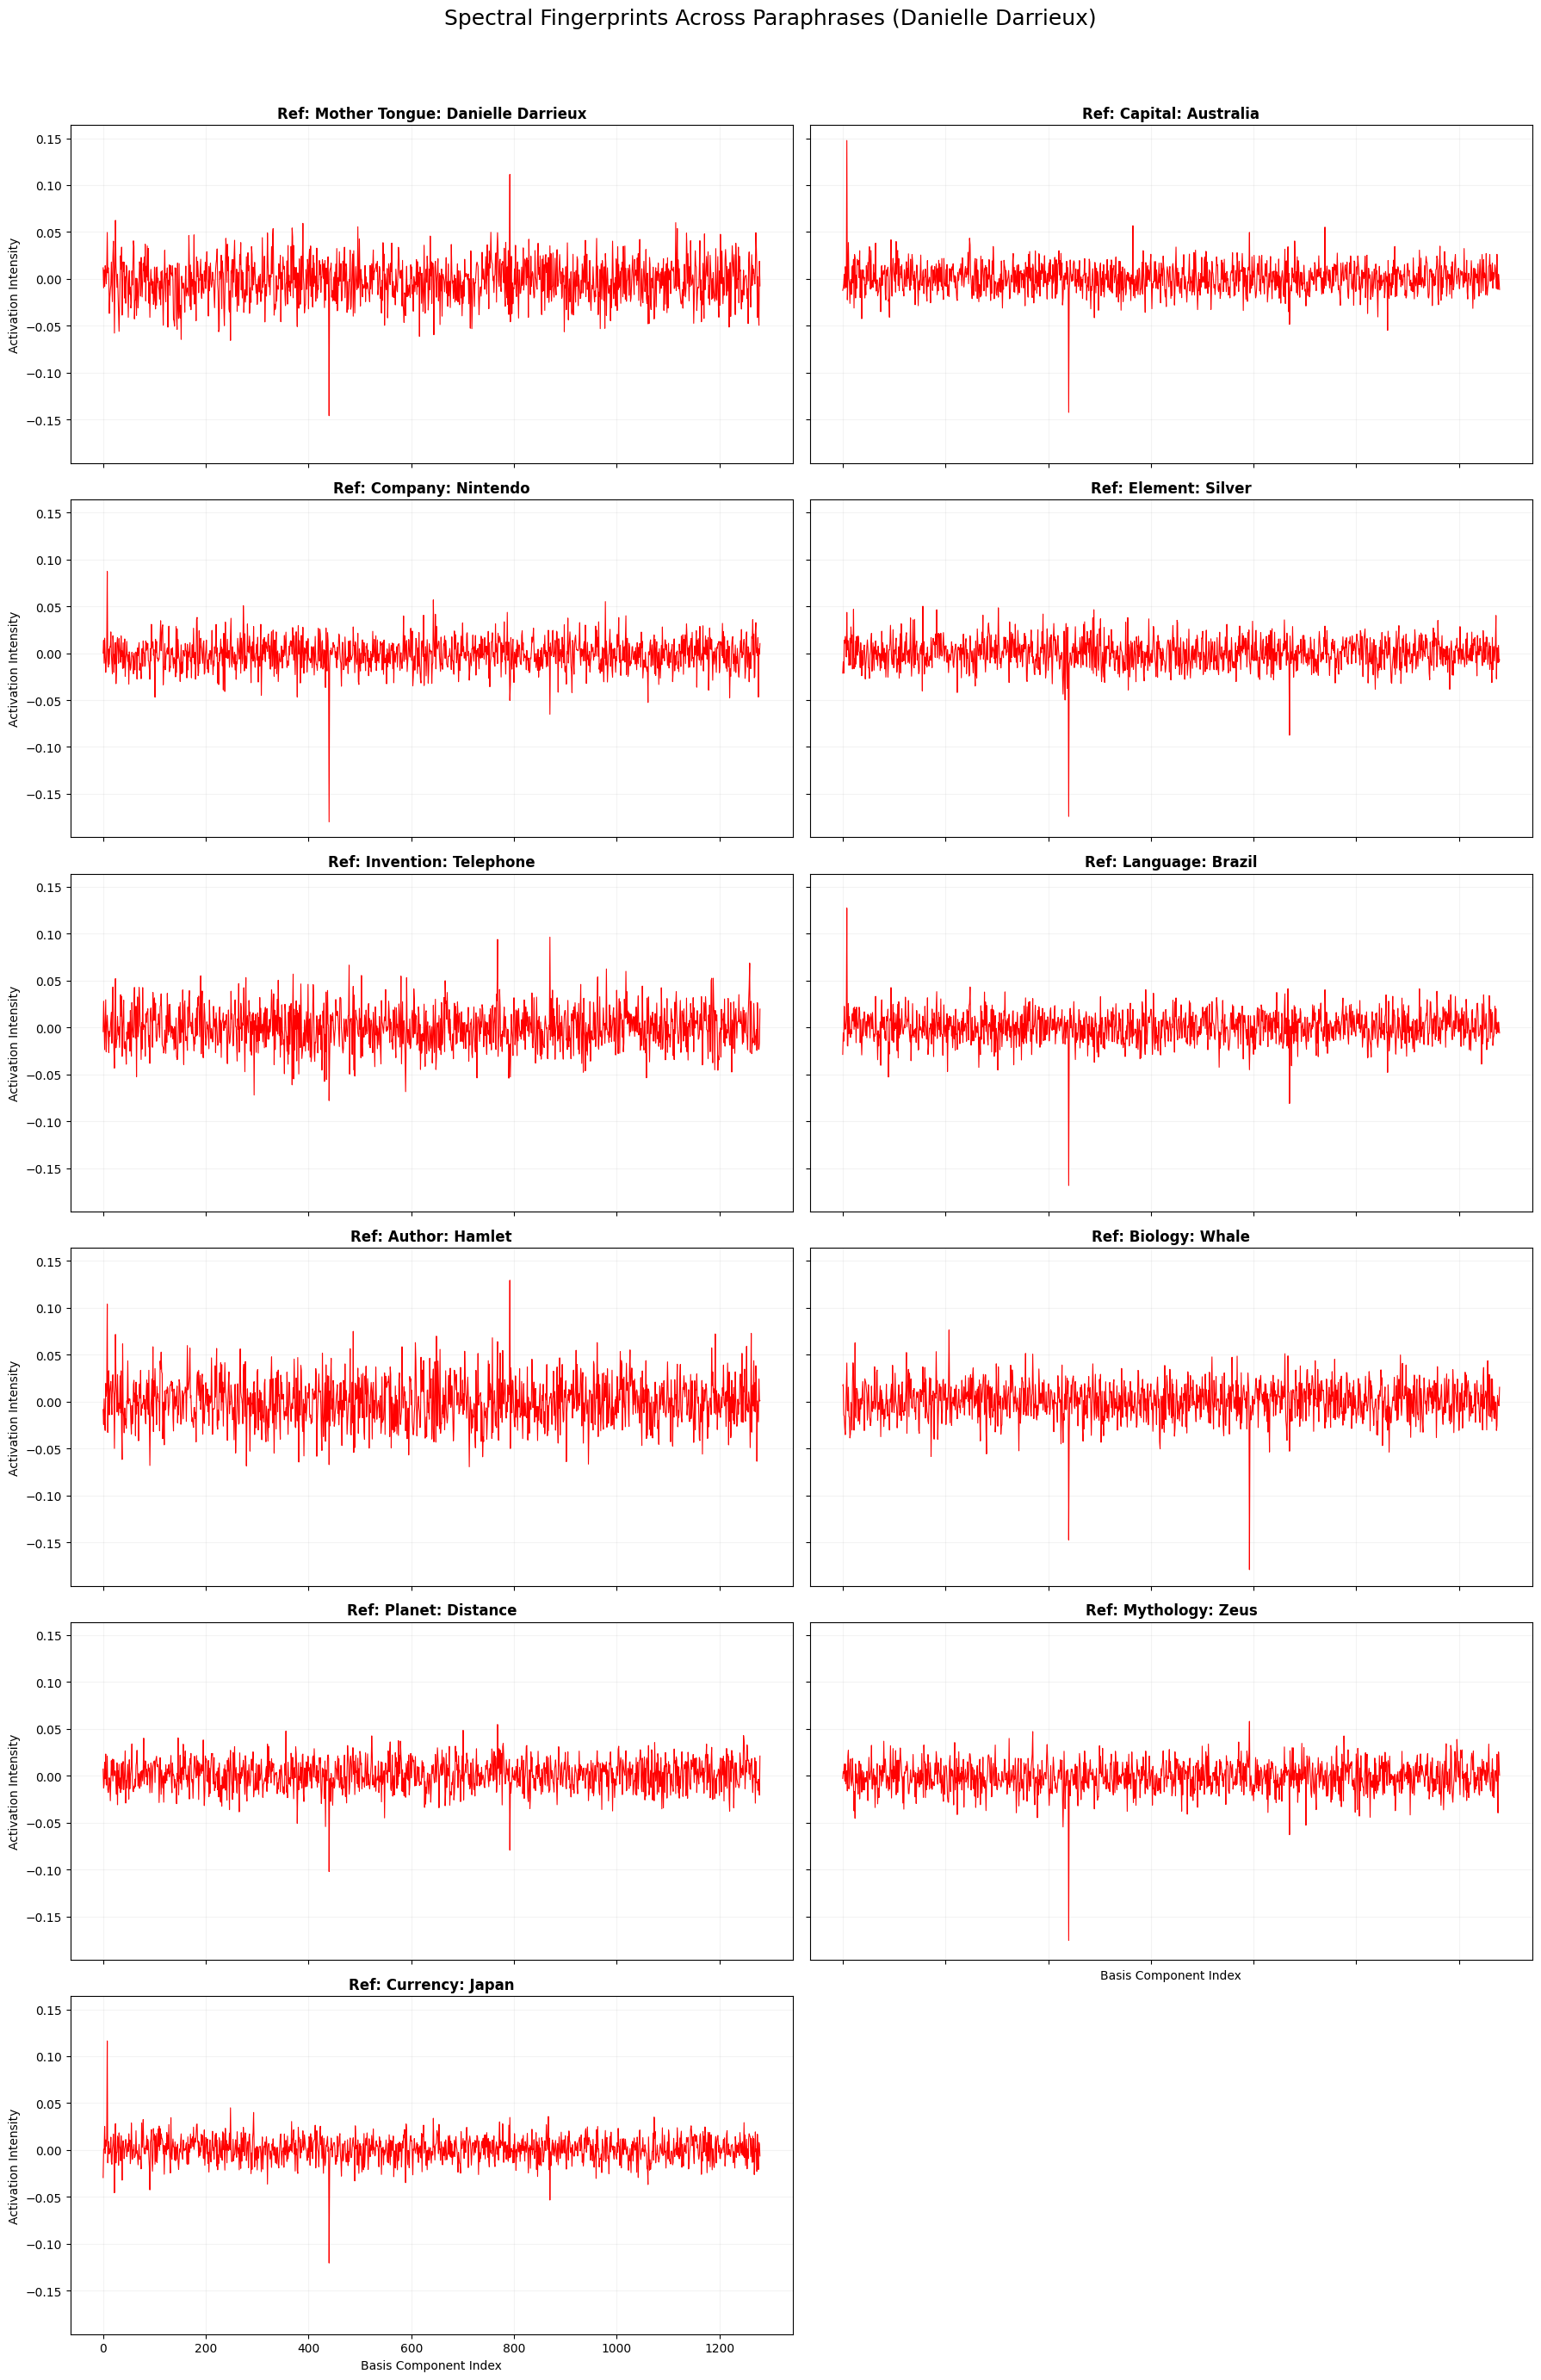

Mother Tongue: Direct tensor(-7.1527, device='cuda:0')
Mother Tongue: Bio tensor(-7.1527, device='cuda:0')
Mother Tongue: Origin tensor(-7.1527, device='cuda:0')
Mother Tongue: Contrast tensor(-7.1528, device='cuda:0')
Mother Tongue: Simple tensor(-7.1526, device='cuda:0')
Mother Tongue: Formal tensor(-7.1527, device='cuda:0')
Mother Tongue: Action tensor(-7.1527, device='cuda:0')
Mother Tongue: Script tensor(-7.1527, device='cuda:0')
Mother Tongue: Short tensor(-7.1528, device='cuda:0')
Mother Tongue: Identity tensor(-7.1527, device='cuda:0')


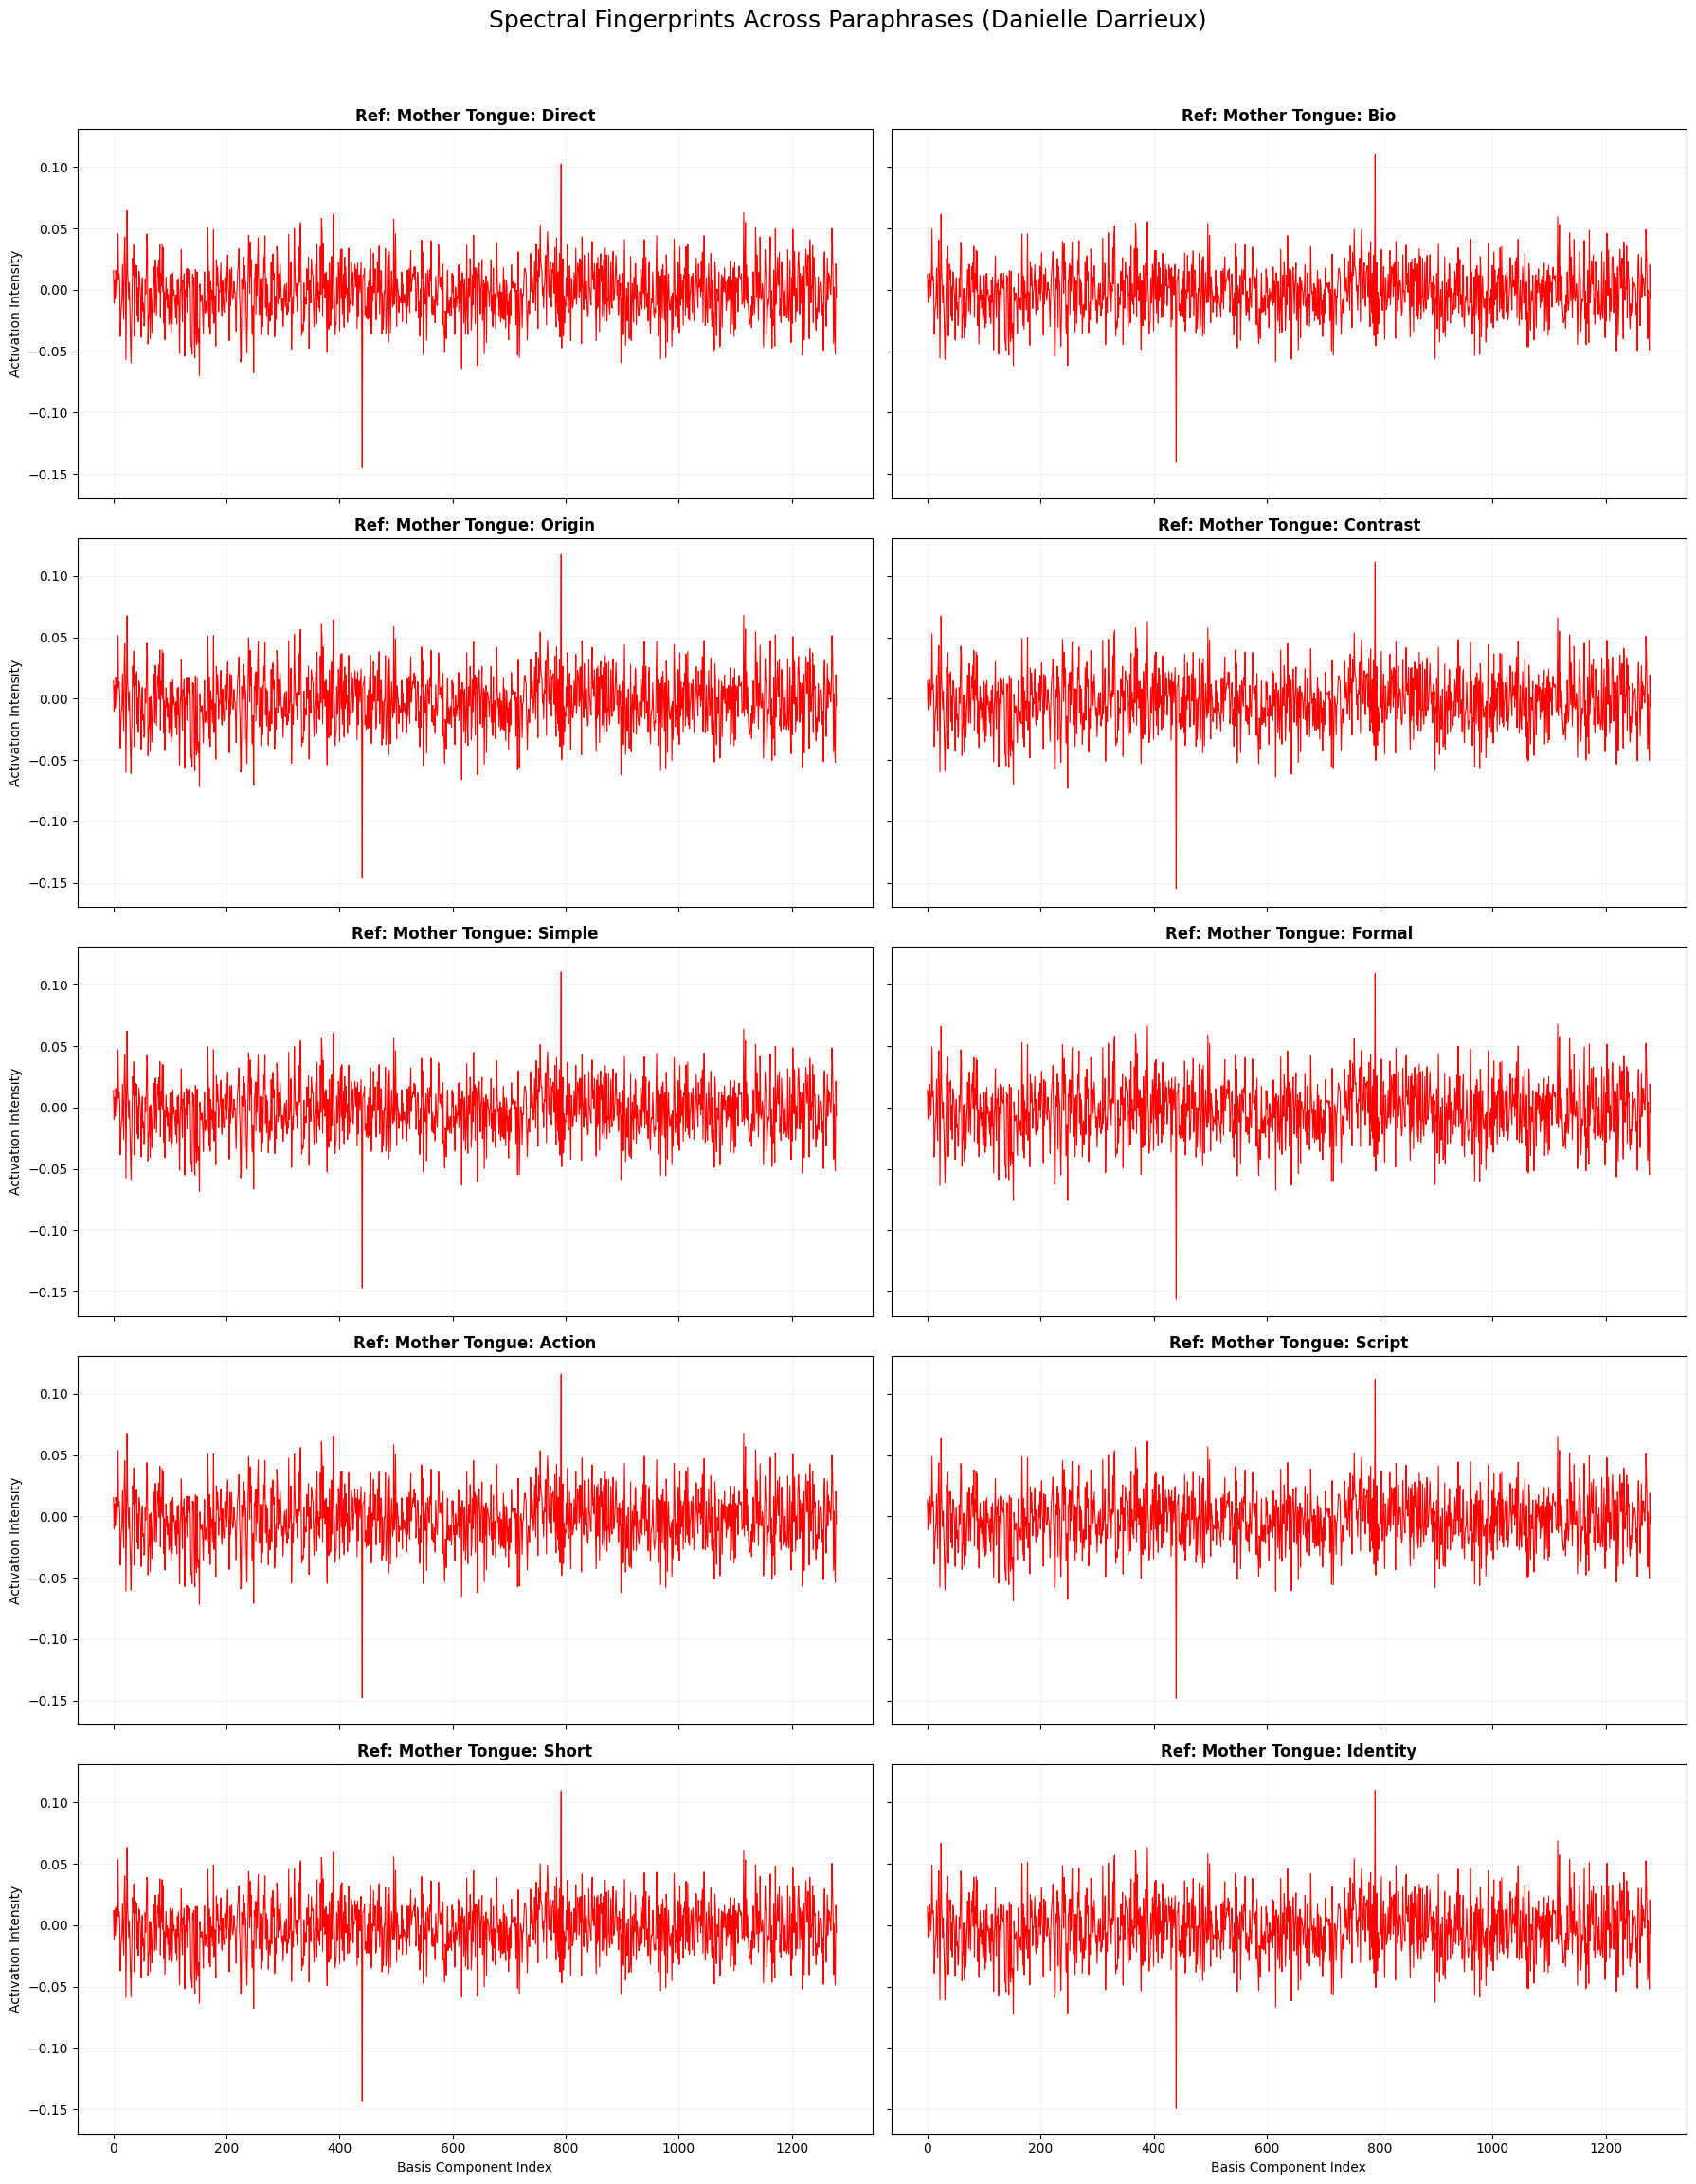

In [8]:
import torch
import matplotlib.pyplot as plt

from src.rome.common import gather_k

# 1. Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
D = D.to(device)
U = U.to(device)

# 2. Define the Paraphrased Prompts
paraphrase_list = [
    ("Original", ("The mother tongue of{} is", " Danielle Darrieux", " English", " French")),
    ("Direct", ("What is the native language of{}?", " Danielle Darrieux", " English", " French")),
    ("Biographical", ("{} grew up speaking the language of", " Danielle Darrieux", " English", " French")),
    ("Origin-based", ("As a French actress, {}'s first language is", " Danielle Darrieux", " English", " French")),
    ("Simple", ("{} is a native speaker of", " Danielle Darrieux", " English", " French")),
    ("Formal", ("The primary language spoken by{} from birth is", " Danielle Darrieux", " English", " French"))
]

def plot_paraphrase_grid(prompts, D, U):
    # Calculate grid size based on prompt count
    n = len(prompts)
    cols = 2
    rows = (n + 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), sharex=True, sharey=True)
    axes = axes.flatten()
    
    def outlier_maximizer(z):
    # Maximizing the logsumexp forces the 'top' values to grow 
    # and the 'bottom' values to shrink.
        return -torch.logsumexp(z, dim=-1)

    for i, (label, prompt_tuple) in enumerate(prompts):
        # Process vector
        k_vec = prompt_tuple
        y = D @ k_vec
        # z_k = U.T @ (D.T @ y)
        z_k = torch.linalg.pinv(U) @ (torch.linalg.pinv(D) @ y)
        print(label, outlier_maximizer(z_k))
        data = z_k.cpu().numpy()
        
        # Plot on specific subplot
        ax = axes[i]
        ax.plot(data, color="r", linewidth=0.8)
        ax.set_title(f"Ref: {label}", fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.15)
        
        # Add labels to the bottom row
        if i >= n - cols:
            ax.set_xlabel("Basis Component Index")
        if i % cols == 0:
            ax.set_ylabel("Activation Intensity")

    # Clean up empty subplots if n is odd
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Spectral Fingerprints Across Paraphrases (Danielle Darrieux)", fontsize=18, y=0.95)
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.show()














k_examples = [
    ("Mother Tongue: Danielle Darrieux", gather_k(handler, ("The mother tongue of{} is", " Danielle Darrieux", " English", " French")).to(device).float().detach()),
    ("Capital: Australia", gather_k(handler, ("The capital of{} is", " Australia", " Sydney", " Canberra")).to(device).float()),
    ("Company: Nintendo", gather_k(handler, ("The headquarters of{} is in", " Nintendo", " Tokyo", " Kyoto")).to(device).float()),
    ("Element: Silver", gather_k(handler, ("The chemical symbol for{} is", " Silver", " Si", " Ag")).to(device).float()),
    ("Invention: Telephone", gather_k(handler, ("The telephone was invented by{}", " Alexander Graham Bell", " Thomas Edison", " Alexander Graham Bell")).to(device).float()),
    ("Language: Brazil", gather_k(handler, ("The official language of{} is", " Brazil", " Spanish", " Portuguese")).to(device).float()),
    ("Author: Hamlet", gather_k(handler, ("The play 'Hamlet' was written by{}", " William Shakespeare", " Christopher Marlowe", " William Shakespeare")).to(device).float()),
    ("Biology: Whale", gather_k(handler, ("A whale is a type of{}", " mammal", " fish", " mammal")).to(device).float()),
    ("Planet: Distance", gather_k(handler, ("The planet closest to the Sun is{}", " Mercury", " Venus", " Mercury")).to(device).float()),
    ("Mythology: Zeus", gather_k(handler, ("In mythology, Zeus is the king of the{} gods", " Greek", " Roman", " Greek")).to(device).float()),
    ("Currency: Japan", gather_k(handler, ("The currency used in{} is the Yen", " Japan", " China", " Japan")).to(device).float())
]

k_dd_examples = [

    # 1. Direct inquiry
("Mother Tongue: Direct", gather_k(handler, ("What is the native language of{}?", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 2. Descriptive/Biographical
("Mother Tongue: Bio", gather_k(handler, ("{} grew up speaking the language of", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 3. Nationalistic association
("Mother Tongue: Origin", gather_k(handler, ("As a French actress, {}'s first language is", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 4. Multilingual contrast
("Mother Tongue: Contrast", gather_k(handler, ("Although she filmed in many countries, {}'s mother tongue remains", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 5. Simple Declarative
("Mother Tongue: Simple", gather_k(handler, ("{} is a native speaker of", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 6. Formal/Encyclopedic
("Mother Tongue: Formal", gather_k(handler, ("The primary language spoken by{} from birth is", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 7. Action-based
("Mother Tongue: Action", gather_k(handler, ("{} first learned to speak in", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 8. Literature/Script context
("Mother Tongue: Script", gather_k(handler, ("The original language used by{} in her early life was", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 9. Short/Elliptical
("Mother Tongue: Short", gather_k(handler, ("{} - Native Language:", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 10. Identity-focused
("Mother Tongue: Identity", gather_k(handler, ("The linguistic identity of{} is centered on", " Danielle Darrieux", " English", " French")).to(device).float().detach())
]


# --- Execute ---
plot_paraphrase_grid(k_examples, D, U)
plot_paraphrase_grid(k_dd_examples, D, U)

In [4]:
import torch
import matplotlib.pyplot as plt

# 1. Automatic Device Detection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure your transformation matrices are on the same device
D = D.to(device)
U = U.to(device)

def plot_knowledge_projection(k_vector, D, U, title="Knowledge Projection"):
    """
    Projects a factual vector k through dictionary D and basis U.
    Calculates: y = Dk, z = U^T(D^T y)
    """
    # Ensure the input k_vector is on the correct device
    k_vector = k_vector.to(device)
    
    # Linear transformations
    y = D @ k_vector
    # z_k = U.T @ (D.T @ y)
    z_k = torch.linalg.pinv(U) @ (torch.linalg.pinv(D) @ y)
    
    # Move back to CPU only for plotting
    projection_data = z_k.detach().cpu().numpy()
    
    plt.figure(figsize=(16, 6))
    plt.plot(projection_data, color="r", linewidth=1.0)
    plt.title(f"Spectral Fingerprint: {title}", fontsize=14)
    plt.xlabel("Basis Index")
    plt.ylabel("Intensity")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    return z_k.detach().cpu()

# --- 2. Define the 10 Knowledge Vectors ---
# Note: we call .to(device) immediately to keep memory management consistent
k_examples = [
    ("Mother Tongue: Danielle Darrieux", gather_k(handler, ("The mother tongue of{} is", " Danielle Darrieux", " English", " French")).to(device).float().detach()),
    ("Capital: Australia", gather_k(handler, ("The capital of{} is", " Australia", " Sydney", " Canberra")).to(device).float()),
    ("Company: Nintendo", gather_k(handler, ("The headquarters of{} is in", " Nintendo", " Tokyo", " Kyoto")).to(device).float()),
    ("Element: Silver", gather_k(handler, ("The chemical symbol for{} is", " Silver", " Si", " Ag")).to(device).float()),
    ("Invention: Telephone", gather_k(handler, ("The telephone was invented by{}", " Alexander Graham Bell", " Thomas Edison", " Alexander Graham Bell")).to(device).float()),
    ("Language: Brazil", gather_k(handler, ("The official language of{} is", " Brazil", " Spanish", " Portuguese")).to(device).float()),
    ("Author: Hamlet", gather_k(handler, ("The play 'Hamlet' was written by{}", " William Shakespeare", " Christopher Marlowe", " William Shakespeare")).to(device).float()),
    ("Biology: Whale", gather_k(handler, ("A whale is a type of{}", " mammal", " fish", " mammal")).to(device).float()),
    ("Planet: Distance", gather_k(handler, ("The planet closest to the Sun is{}", " Mercury", " Venus", " Mercury")).to(device).float()),
    ("Mythology: Zeus", gather_k(handler, ("In mythology, Zeus is the king of the{} gods", " Greek", " Roman", " Greek")).to(device).float()),
    ("Currency: Japan", gather_k(handler, ("The currency used in{} is the Yen", " Japan", " China", " Japan")).to(device).float())
]

k_dd_examples = [

    # 1. Direct inquiry
("Mother Tongue: Direct", gather_k(handler, ("What is the native language of{}?", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 2. Descriptive/Biographical
("Mother Tongue: Bio", gather_k(handler, ("{} grew up speaking the language of", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 3. Nationalistic association
("Mother Tongue: Origin", gather_k(handler, ("As a French actress, {}'s first language is", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 4. Multilingual contrast
("Mother Tongue: Contrast", gather_k(handler, ("Although she filmed in many countries, {}'s mother tongue remains", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 5. Simple Declarative
("Mother Tongue: Simple", gather_k(handler, ("{} is a native speaker of", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 6. Formal/Encyclopedic
("Mother Tongue: Formal", gather_k(handler, ("The primary language spoken by{} from birth is", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 7. Action-based
("Mother Tongue: Action", gather_k(handler, ("{} first learned to speak in", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 8. Literature/Script context
("Mother Tongue: Script", gather_k(handler, ("The original language used by{} in her early life was", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 9. Short/Elliptical
("Mother Tongue: Short", gather_k(handler, ("{} - Native Language:", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 10. Identity-focused
("Mother Tongue: Identity", gather_k(handler, ("The linguistic identity of{} is centered on", " Danielle Darrieux", " English", " French")).to(device).float().detach())
]

# --- 3. Execute ---
data = []
for label, k_vec in k_examples:
    data.append(plot_knowledge_projection(k_vec, D, U, title=label))

for label, k_vec in k_dd_examples:
    data.append(plot_knowledge_projection(k_vec, D, U, title=label))

NameError: name 'gather_k' is not defined

In [ ]:
from src.rome.common import gather_k

# TODO: gather k BEFORE the up projection
k_mother = gather_k(handler, ("The mother tongue of{} is", " Danielle Darrieux", " English", " French")).float().detach()

# 1. Geography: Capital Distractor
k_cap = gather_k(handler, ("The capital of{} is", " Australia", " Sydney", " Canberra")).float().detach()

# 2. Tech: Company Headquarters
k_corp = gather_k(handler, ("The headquarters of{} is in", " Nintendo", " Tokyo", " Kyoto")).float().detach()

# 3. Science: Chemical Symbols
k_chem = gather_k(handler, ("The chemical symbol for{} is", " Silver", " Si", " Ag")).float().detach()

# 4. History: Inventions
k_inv = gather_k(handler, ("The telephone was invented by{}", " Alexander Graham Bell", " Thomas Edison", " Alexander Graham Bell")).float().detach()

# 5. Language: Regional Official Languages
k_lang = gather_k(handler, ("The official language of{} is", " Brazil", " Spanish", " Portuguese")).cpu().float().detach()

# 6. Literature: Famous Authors
k_auth = gather_k(handler, ("The play 'Romeo and Juliet' was written by{}", " William Shakespeare", " Christopher Marlowe", " William Shakespeare")).cpu().float().detach()

# 7. Biology: Classification
k_bio = gather_k(handler, ("A whale is a type of{}", " mammal", " fish", " mammal")).cpu().float().detach()

# 8. Astronomy: Planet Order
k_planet = gather_k(handler, ("The planet closest to the Sun is{}", " Mercury", " Venus", " Mercury")).cpu().float().detach()

# 9. Mythology: Origins
k_myth = gather_k(handler, ("In mythology, Zeus is the king of the{} gods", " Greek", " Roman", " Greek")).cpu().float().detach()

# 10. Economics: Currency
k_curr = gather_k(handler, ("The currency used in{} is the Yen", " Japan", " China", " Japan")).cpu().float().detach()

import matplotlib.pyplot as plt
y = D @ k_cap
z_k = U.T @ (D.T @ y)
fig = plt.figure(figsize=(16,10))
ax = plt.axes()
ax.plot(z_k.cpu(), color="r")
plt.show()

y = D @ k_corp
z_k = U.T @ (D.T @ y)
fig = plt.figure(figsize=(16,10))
ax = plt.axes()
ax.plot(z_k.cpu(), color="r")
plt.show()

y = D @ k_chem
z_k = U.T @ (D.T @ y)
fig = plt.figure(figsize=(16,10))
ax = plt.axes()
ax.plot(z_k.cpu(), color="r")
plt.show()

y = D @ k_inv
z_k = U.T @ (D.T @ y)
fig = plt.figure(figsize=(16,10))
ax = plt.axes()
ax.plot(z_k.cpu(), color="r")
plt.show()

In [3]:
import numpy as np
from omegaconf import DictConfig

import sys
import os

from tqdm import tqdm
sys.path.insert(0, os.path.abspath('..'))

from src.handlers.rome import ModelHandler

cfg = DictConfig({
    "model": {
        "name": "gpt2-large",
        "models_dir": "../../models",
        "second_moment_dir": "../data/second_moment_stats",
        "new_weights_dir": "../data/new_weights",
        "device": "cuda",
        "save_to_local": True, # Keep this True until you specifically do not want the model cached locally
        "layer_name_template": "transformer.h.{}.mlp.c_proj",
        "restore_layer_name_template": "transformer.h.{}",
        "corrupt_layer_name_template": "transformer.wte",
        "layer": 12,
        "corruption_noise_multiplier": 0.1380615234375,
        "lr": 0.5,
        "kl_factor": 0.0625,
        "weight_decay": 0.5,
        "epochs": 20,
        "epsilon": 0.0,
        "optimize_pcs": False,
        "dtype": "bf16"

    },
    "generation": None,
    "dataset_sm": None,
    "dataset_facts": {
        "name": "azhx/counterfact",
        "concat_splits": ["train", "test"],
        "datasets_dir": "../../datasets",
        "save_to_local": True
    },})

handler = ModelHandler(cfg)

from torch.optim import Adam
from src.rome.rome import batch_intervention_generator
from torch.utils.tensorboard import SummaryWriter

import torch
import torch.fft as fft

writer = SummaryWriter(f'runs/involution_rome')

layer=12
U = handler.model.transformer.h[layer].mlp.c_fc.weight.cpu().detach().float().T
D = handler.model.transformer.h[layer].mlp.c_proj.weight.cpu().detach().float().T

def zbryndza_loss(output, target):
    for shift in range(640):
        shifted_output = torch.roll(output, shifts=shift, dims=-1)
        correlation = (shifted_output.abs() - target.abs()).sum().abs()
        if shift == 0:
            max_correlation = correlation
        else:
            max_correlation = torch.min(max_correlation, correlation)
    return max_correlation

import torch.nn.functional as F
def entropy_loss(logits, T=1.5):
    """
    Calculates Shannon Entropy with Temperature Scaling.
    
    Args:
        logits (torch.Tensor): Raw output from the network (before softmax).
        T (float): Temperature parameter. T > 1 softens the distribution.
    """
    # 1. Scale logits by Temperature
    scaled_logits = logits / T
    
    # 2. Get stable log-probabilities
    log_probs = F.log_softmax(scaled_logits, dim=-1)
    
    # 3. Get probabilities for the weighted sum
    probs = torch.exp(log_probs)
    
    # 4. Calculate Entropy: -sum(p * log_p)
    # We sum across the last dimension (the bins/classes)
    entropy = -torch.sum(probs * log_probs, dim=-1)
    
    # Return the mean entropy across the batch
    if not entropy.mean():
        print(logits)
    return entropy.mean()

counter = 1
for new_W, old_W, prompt_dict, success in batch_intervention_generator(handler):
    if counter == 0:
        break
    new_D = new_W.cpu().detach().float().T

    writer = SummaryWriter(f'runs/involution_rome_{prompt_dict.case_id}_{"success" if success else "failure"}')

    # x = gather_k(handler, ("The mother tongue of{} is", " Danielle Darrieux", " English", " French")).cpu().float()
    count = 1

    acc = 0.0
    for _ in tqdm(range(count)):
        x_raw = torch.randn(U.shape[1], requires_grad=True)
        opt = Adam([x_raw], lr=1e-5)
        
        acc_l_o = 0.0
        acc_l_r = 0.0

        for i in range(count):
            opt.zero_grad()
            x = F.normalize(x_raw, p=2, dim=0)

            y = new_D @ (U @ x)
            z = U.T @ (new_D.T @ y)
            
            # y = new_D @ x
            # y = D @ (U @ x)
            # z = U.T @ (D.T @ y)

            # loss = zbryndza_loss(ref, z*(z.mean()/z.mean().abs())) / norm
            # acc_l_o += -1.0 * entropy_loss(z_o)
            loss = -1.0 * entropy_loss(z)

            if loss <= -5.0:
                break

            # if i % 10 == 0:
                # print(f"Epoch {i} loss: {loss}")

            # writer.add_scalar('Loss', loss.item(), i)
            
            loss.backward()
            opt.step()
        
        acc += i

    print("ROME:", acc/count * 100)


    acc = 0.0
    for _ in tqdm(range(count)):
        x_raw = torch.randn(U.shape[1], requires_grad=True)
        opt = Adam([x_raw], lr=1e-3)
        
        acc_l_o = 0.0
        acc_l_r = 0.0

        for i in range(count):
            opt.zero_grad()
            x = F.normalize(x_raw, p=2, dim=0)

            # y = new_D @ (U @ x)
            # z = U.T @ (new_D.T @ y)
            
            # y = new_D @ x
            y = D @ (U @ x)
            z = U.T @ (D.T @ y)

            # loss = zbryndza_loss(ref, z*(z.mean()/z.mean().abs())) / norm
            # acc_l_o += -1.0 * entropy_loss(z_o)
            loss = -1.0 * entropy_loss(z)

            if loss <= -1.0:
                break

            # if i % 10 == 0:
                # print(f"Epoch {i} loss: {loss}")

            # writer.add_scalar('Loss', loss.item(), i)
            
            loss.backward()
            opt.step()
        
        acc += i

    print("ORIG:", acc/count * 100)
    
    counter -= 1

No HuggingFace token found in HF_TOKEN environment variable. Consider setting it for faster model/dataset loading from the Hub.
Loading weights: 100%|██████████| 436/436 [00:00<00:00, 981.19it/s, Materializing param=transformer.wte.weight]              
No HuggingFace token found in HF_TOKEN environment variable. Consider setting it for faster model/dataset loading from the Hub.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
100%|██████████| 1/1 [00:00<00:00, 106.61it/s]


ROME: 0.0


100%|██████████| 1/1 [00:00<00:00, 105.24it/s]
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


ORIG: 0.0


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [ ]:
import numpy as np
from omegaconf import DictConfig

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

from src.handlers.rome import ModelHandler
from tqdm import tqdm

cfg = DictConfig({
    "model": {
        "name": "gpt2-large",
        "models_dir": "../../models",
        "second_moment_dir": "../data/second_moment_stats",
        "new_weights_dir": "../data/new_weights",
        "device": "cuda",
        "save_to_local": True, # Keep this True until you specifically do not want the model cached locally
        "layer_name_template": "transformer.h.{}.mlp.c_proj",
        "restore_layer_name_template": "transformer.h.{}",
        "corrupt_layer_name_template": "transformer.wte",
        "layer": 12,
        "corruption_noise_multiplier": 0.1380615234375,
        "lr": 0.5,
        "kl_factor": 0.0625,
        "weight_decay": 0.5,
        "epochs": 20,
        "epsilon": 0.0,
        "optimize_pcs": False,
        "dtype": "bf16"

    },
    "generation": None,
    "dataset_sm": None,
    "dataset_facts": {
        "name": "azhx/counterfact",
        "concat_splits": ["train", "test"],
        "datasets_dir": "../../datasets",
        "save_to_local": True
    },})

handler = ModelHandler(cfg)

from torch.optim import Adam
from src.rome.rome import batch_intervention_generator
from torch.utils.tensorboard import SummaryWriter

import torch
import torch.fft as fft


layer=12
U = handler.model.transformer.h[layer].mlp.c_fc.weight.detach().float().T
D = handler.model.transformer.h[layer].mlp.c_proj.weight.detach().float().T

def zbryndza_loss(ref_l, test_l):
    ref = ref_l.abs()
    test = test_l.abs()
    for shift in range(ref.shape[0]//2):
        shifted_output = torch.roll(ref, shifts=shift, dims=-1)
        correlation = (shifted_output - test).abs().sum()
        if shift == 0:
            max_correlation = correlation
        else:
            max_correlation = torch.min(max_correlation, correlation)
    return max_correlation

import torch.nn.functional as F
def entropy_loss(logits, reduction='mean'):
    # 1. Convert raw network outputs (logits) to probabilities
    probs = F.softmax(logits, dim=-1)
    
    # 2. Calculate log-probabilities (more stable than log(probs))
    log_probs = F.log_softmax(logits, dim=-1)
    
    # 3. Compute Shannon Entropy: -sum(p * log(p))
    # We use 'sum' over the classes dimension
    entropy = -(probs * log_probs).sum(dim=-1)
    
    if reduction == 'mean':
        return entropy.mean()
    return entropy

N = 10000

counter = 1
for new_D, _, prompt_dict, success in batch_intervention_generator(handler):
    if counter == 0:
        break
    writer = SummaryWriter(f'runs/involution_rome_{prompt_dict.case_id}_{"success" if success else "failure"}_{N}')

    new_D = new_D.detach().float().T

    x1 = torch.ones(U.shape[1], device="cuda")
    y = new_D @ (U @ x1)
    ref = U.T @ (new_D.T @ y)
    ref = ref.detach()
    
    for i in tqdm(range(N)):
        x = torch.rand(U.shape[1], device="cuda")
        
        y = D @ (U @ x)
        z_o = U.T @ (D.T @ y)

        y = new_D @ (U @ x)
        z_r = U.T @ (new_D.T @ y)

        # loss_o = zbryndza_loss(ref, z_o)
        # loss_r = zbryndza_loss(ref, z_r)
        loss_o = entropy_loss(z_o)
        loss_r = entropy_loss(z_r)
        writer.add_scalar('Loss original', loss_o.item(), i)
        writer.add_scalar('Loss ROME', loss_r.item(), i)

    counter -= 1

In [ ]:
def plot_paraphrase_grid(prompts, D, U):
    # Calculate grid size based on prompt count
    n = len(prompts)
    cols = 2
    rows = (n + 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), sharex=True, sharey=True)
    axes = axes.flatten()
    
    def outlier_maximizer(z):
    # Maximizing the logsumexp forces the 'top' values to grow 
    # and the 'bottom' values to shrink.
        return -torch.logsumexp(z, dim=-1)

    for i, (label, prompt_tuple) in enumerate(prompts):
        # Process vector
        k_vec = prompt_tuple
        y = D @ k_vec
        z_k = U.T @ (D.T @ y)
        # z_k = torch.linalg.pinv(U) @ (torch.linalg.pinv(D) @ y)
        print(label, outlier_maximizer(z_k))
        data = z_k.cpu().numpy()
        
        # Plot on specific subplot
        ax = axes[i]
        ax.plot(data, color="r", linewidth=0.8)
        ax.set_title(f"Ref: {label}", fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.15)
        
        # Add labels to the bottom row
        if i >= n - cols:
            ax.set_xlabel("Basis Component Index")
        if i % cols == 0:
            ax.set_ylabel("Activation Intensity")

    # Clean up empty subplots if n is odd
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Spectral Fingerprints Across Paraphrases (Danielle Darrieux)", fontsize=18, y=0.95)
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.show()

No HuggingFace token found in HF_TOKEN environment variable. Consider setting it for faster model/dataset loading from the Hub.
Loading weights: 100%|██████████| 436/436 [00:00<00:00, 1163.47it/s, Materializing param=transformer.wte.weight]            
No HuggingFace token found in HF_TOKEN environment variable. Consider setting it for faster model/dataset loading from the Hub.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Mother Tongue: Danielle Darrieux tensor(-7.1595, device='cuda:0')
Capital: Australia tensor(-7.1555, device='cuda:0')
Company: Nintendo tensor(-7.1538, device='cuda:0')
Element: Silver tensor(-7.1549, device='cuda:0')
Invention: Telephone tensor(-7.1553, device='cuda:0')
Language: Brazil tensor(-7.1550, device='cuda:0')
Author: Hamlet tensor(-7.1552, device='cuda:0')
Biology: Whale tensor(-7.1558, device='cuda:0')
Planet: Distance tensor(-7.1564, device='cuda:0')
Mythology: Zeus tensor(-7.1535, device='cuda:0')
Currency: Japan tensor(-7.1558, device='cuda:0')


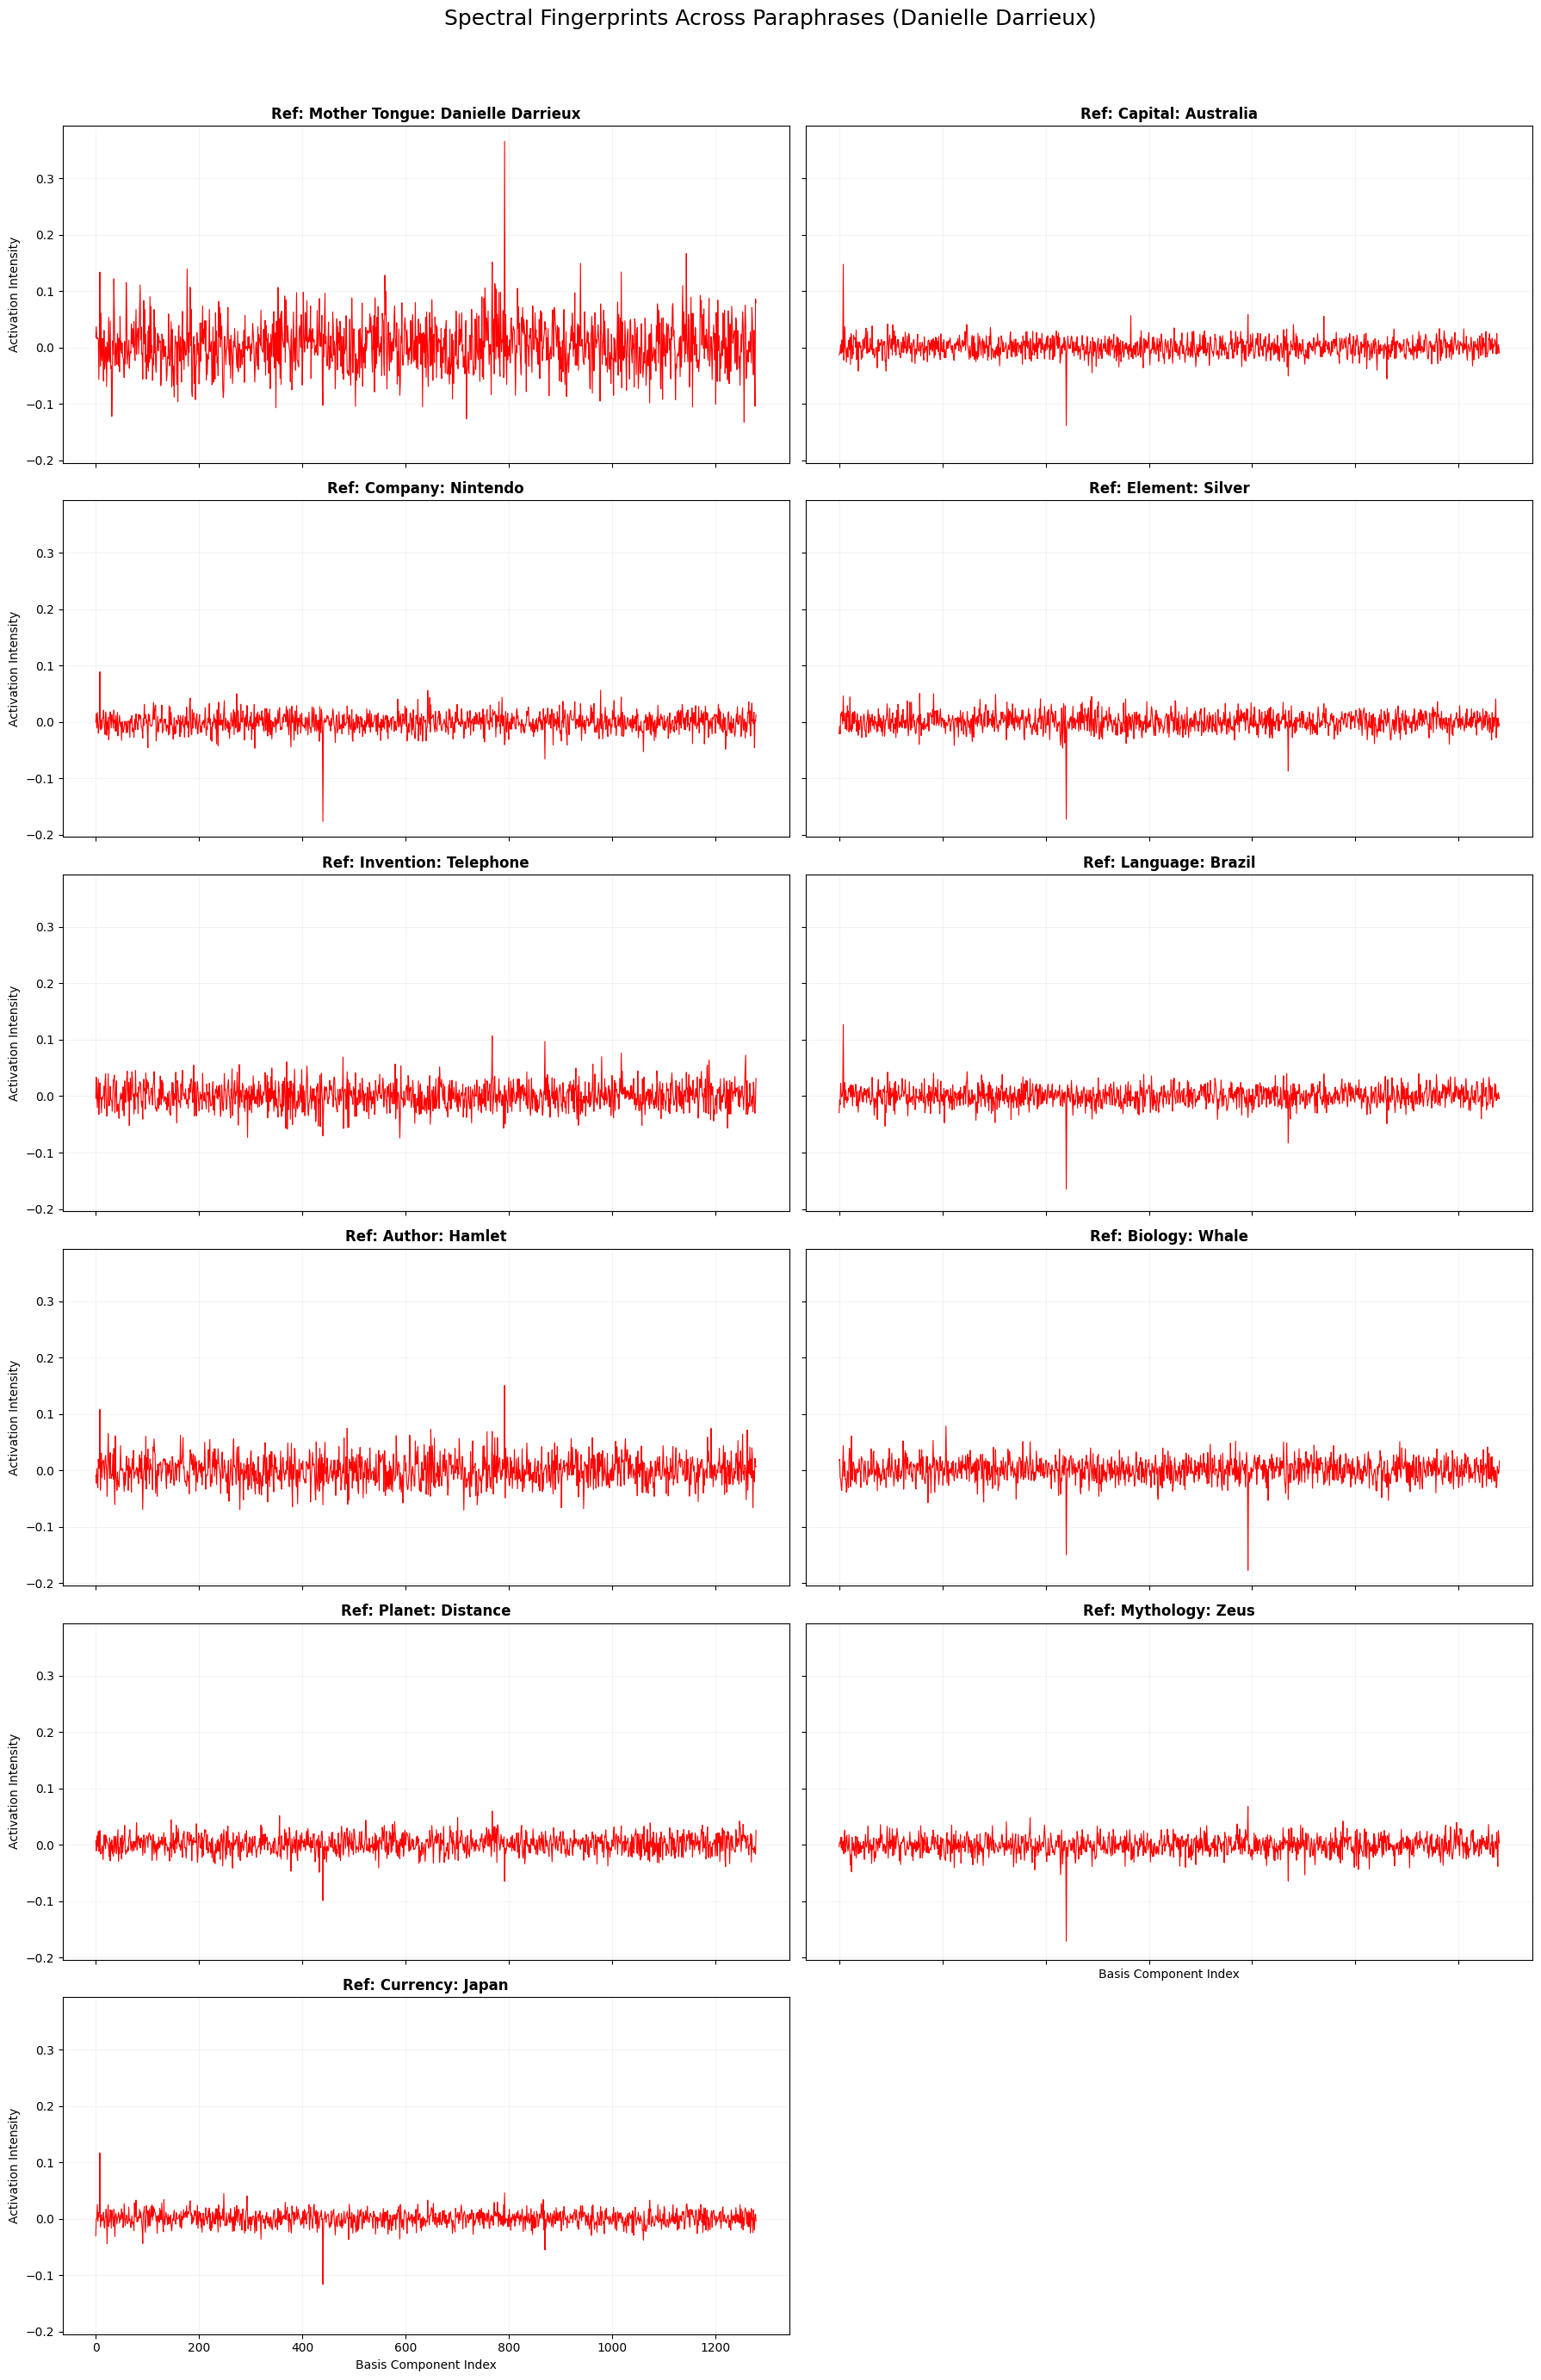

Mother Tongue: Direct tensor(-7.1597, device='cuda:0')
Mother Tongue: Bio tensor(-7.1594, device='cuda:0')
Mother Tongue: Origin tensor(-7.1601, device='cuda:0')
Mother Tongue: Contrast tensor(-7.1600, device='cuda:0')
Mother Tongue: Simple tensor(-7.1597, device='cuda:0')
Mother Tongue: Formal tensor(-7.1603, device='cuda:0')
Mother Tongue: Action tensor(-7.1601, device='cuda:0')
Mother Tongue: Script tensor(-7.1598, device='cuda:0')
Mother Tongue: Short tensor(-7.1597, device='cuda:0')
Mother Tongue: Identity tensor(-7.1601, device='cuda:0')


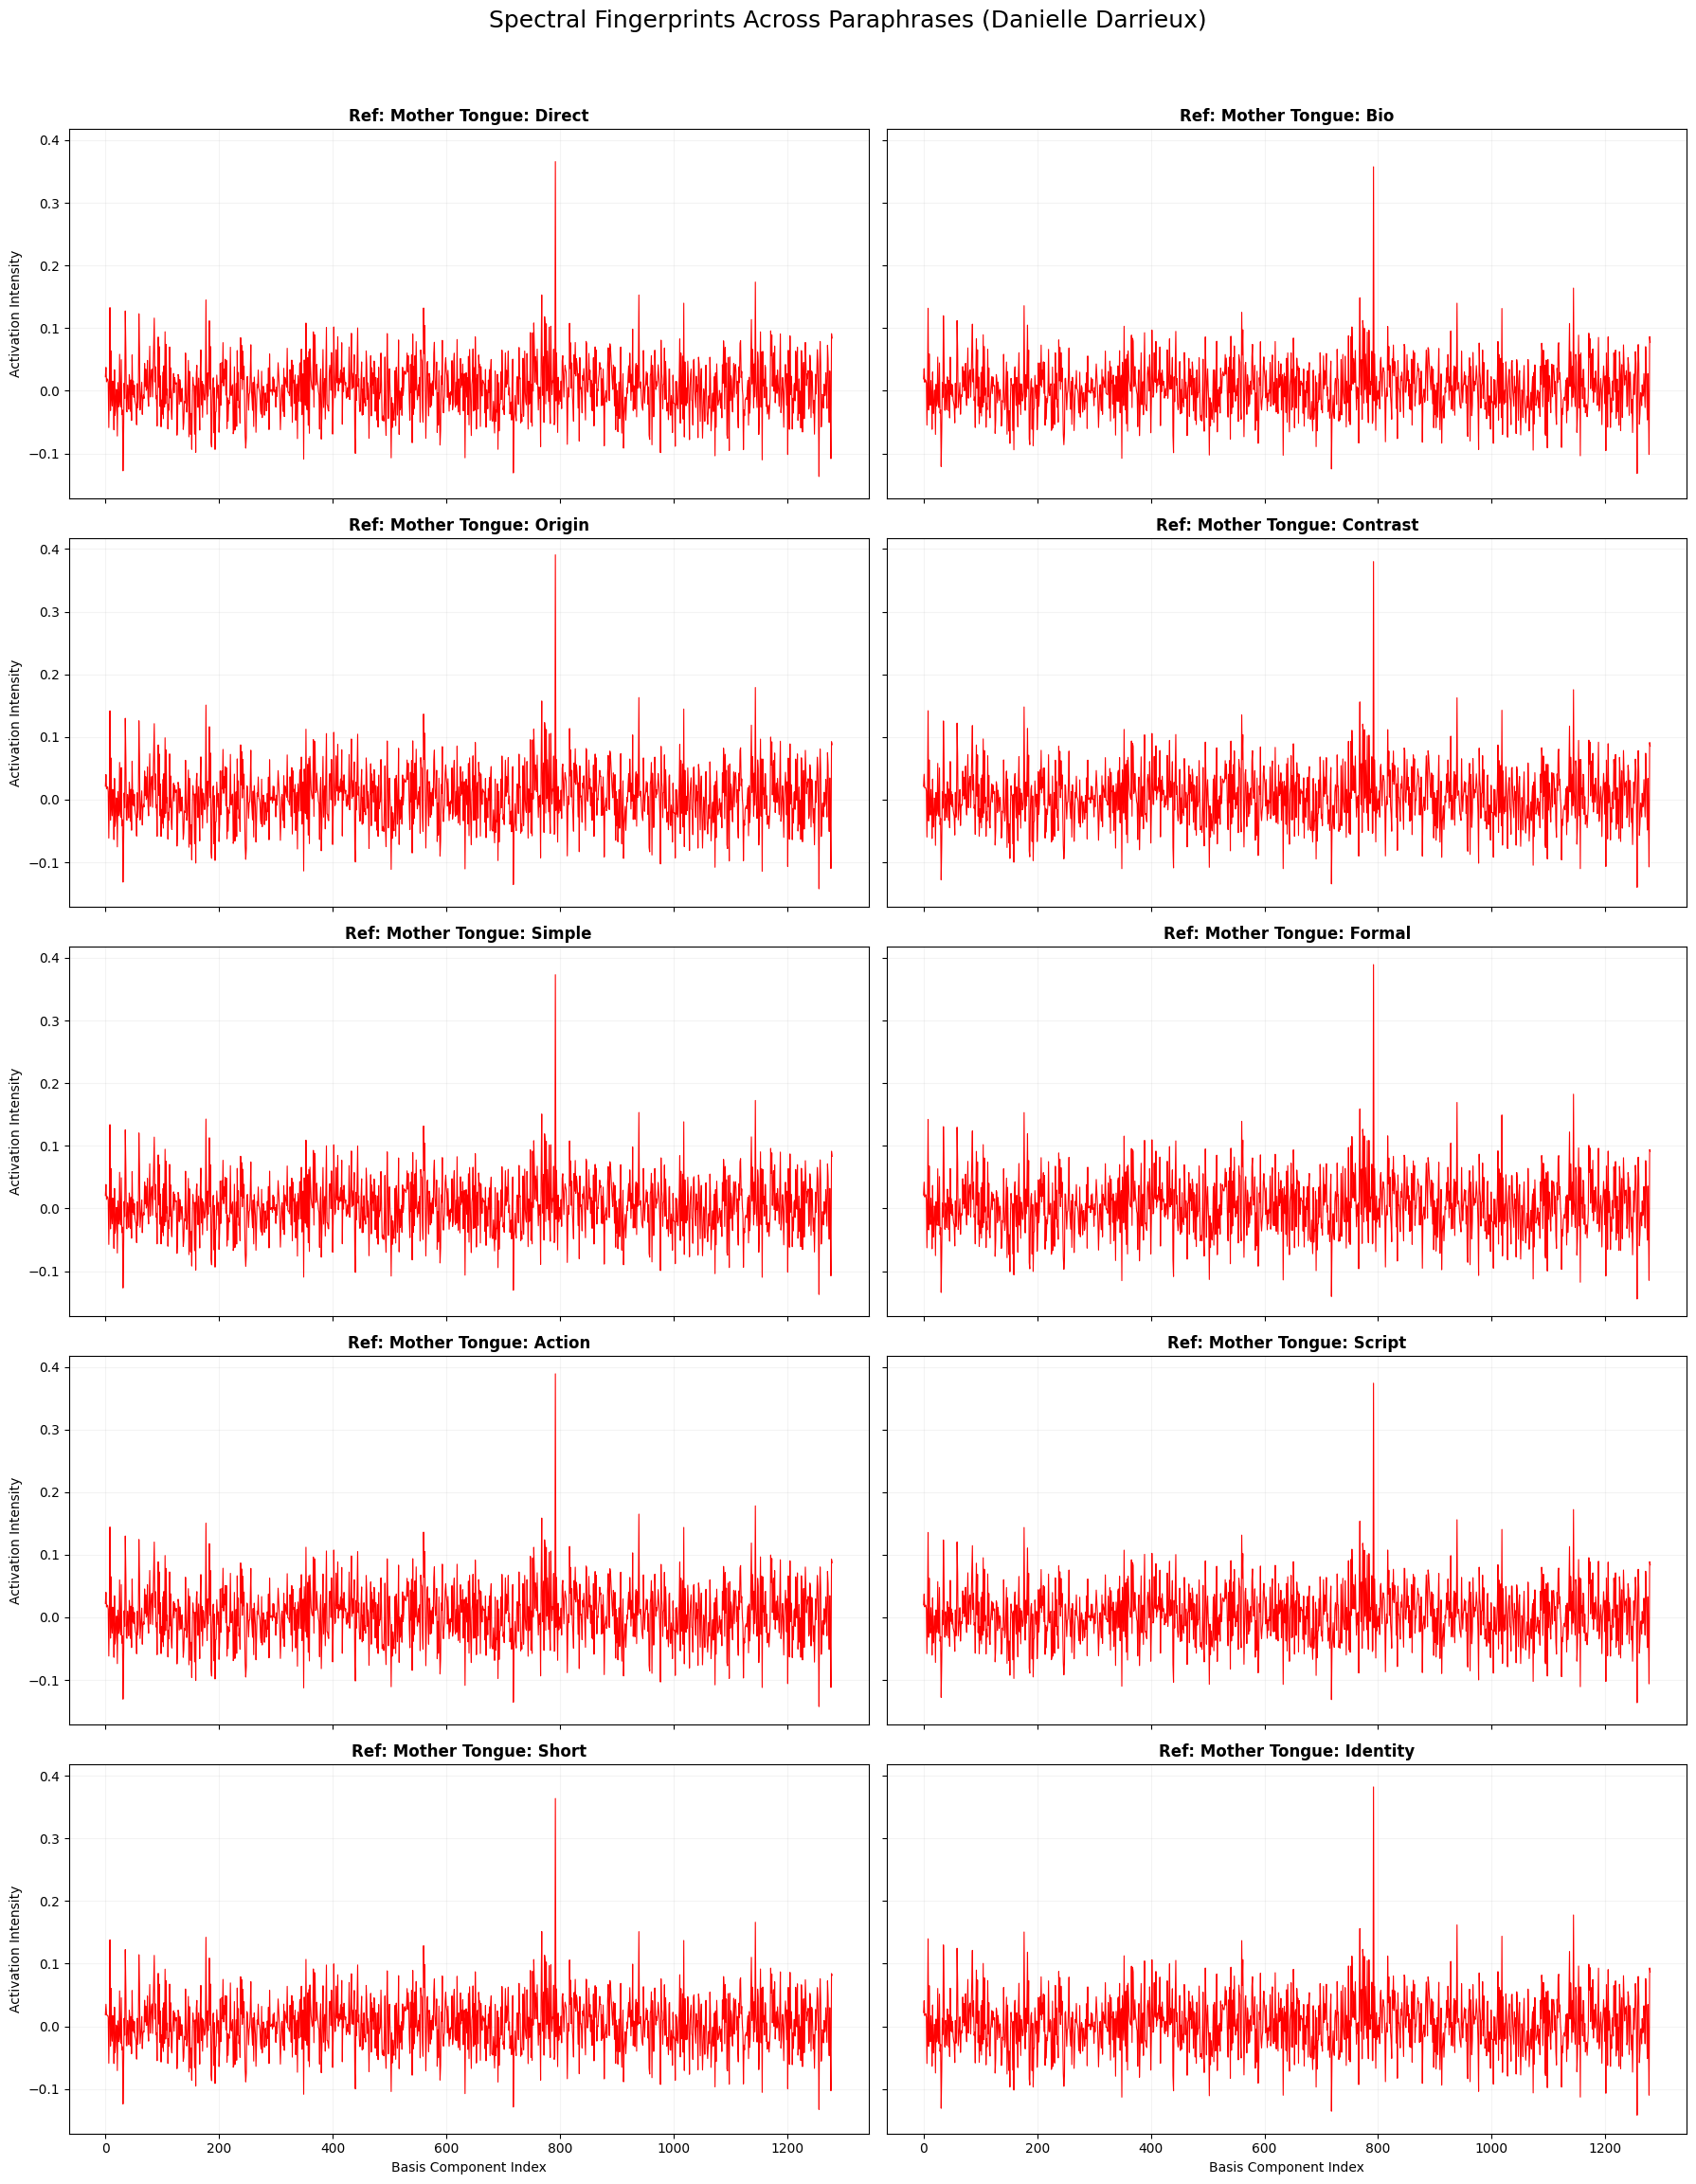

In [9]:
import numpy as np
from omegaconf import DictConfig

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

from src.handlers.rome import ModelHandler
from tqdm import tqdm

cfg = DictConfig({
    "model": {
        "name": "gpt2-large",
        "models_dir": "../../models",
        "second_moment_dir": "../data/second_moment_stats",
        "new_weights_dir": "../data/new_weights",
        "device": "cuda",
        "save_to_local": True, # Keep this True until you specifically do not want the model cached locally
        "layer_name_template": "transformer.h.{}.mlp.c_proj",
        "restore_layer_name_template": "transformer.h.{}",
        "corrupt_layer_name_template": "transformer.wte",
        "layer": 12,
        "corruption_noise_multiplier": 0.1380615234375,
        "lr": 0.5,
        "kl_factor": 0.0625,
        "weight_decay": 0.5,
        "epochs": 20,
        "epsilon": 0.0,
        "optimize_pcs": False,
        "dtype": "bf16"

    },
    "generation": None,
    "dataset_sm": None,
    "dataset_facts": {
        "name": "azhx/counterfact",
        "concat_splits": ["train", "test"],
        "datasets_dir": "../../datasets",
        "save_to_local": True
    },})

handler = ModelHandler(cfg)

from torch.optim import Adam
from src.rome.rome import batch_intervention_generator
from torch.utils.tensorboard import SummaryWriter

import torch
import torch.fft as fft


layer=12
U = handler.model.transformer.h[layer].mlp.c_fc.weight.detach().float().T
D = handler.model.transformer.h[layer].mlp.c_proj.weight.detach().float().T

def zbryndza_loss(ref, test):
    for shift in range(ref.shape[0]//2):
        shifted_output = torch.roll(ref, shifts=shift, dims=-1)
        correlation = (shifted_output - test).abs().sum()
        if shift == 0:
            max_correlation = correlation
        else:
            max_correlation = torch.min(max_correlation, correlation)
    return max_correlation

import torch.nn.functional as F
def entropy_loss(logits, reduction='mean'):
    # 1. Convert raw network outputs (logits) to probabilities
    probs = F.softmax(logits, dim=-1)
    
    # 2. Calculate log-probabilities (more stable than log(probs))
    log_probs = F.log_softmax(logits, dim=-1)
    
    # 3. Compute Shannon Entropy: -sum(p * log(p))
    # We use 'sum' over the classes dimension
    entropy = -(probs * log_probs).sum(dim=-1)
    
    if reduction == 'mean':
        return entropy.mean()
    return entropy

N = 100000

counter = 1
for new_D, _, prompt_dict, success in batch_intervention_generator(handler):
    if counter == 0:
        break
    writer = SummaryWriter(f'runs/involution_rome_{prompt_dict.case_id}_{"success" if success else "failure"}_{N}')

    new_D = new_D.detach().float().T

    x1 = torch.ones(U.shape[1], device="cuda")
    y = new_D @ (U @ x1)
    ref = U.T @ (new_D.T @ y)
    ref = ref.detach()

    # data = []
    # for label, k_vec in k_examples:
    #     data.append(plot_knowledge_projection(k_vec, new_D, U, title=label))

    # print(zbryndza_loss(data[1], data[2]))
    # print(zbryndza_loss(data[0], data[1]))

    plot_paraphrase_grid(k_examples, new_D, U)
    plot_paraphrase_grid(k_dd_examples, new_D, U)

    break

    for i in tqdm(range(N)):
        x = torch.rand(U.shape[1], device="cuda")
        
        y = D @ (U @ x)
        z_o = U.T @ (D.T @ y)

        y = new_D @ (U @ x)
        z_r = U.T @ (new_D.T @ y)

        loss_o = zbryndza_loss(ref, z_o)
        loss_r = zbryndza_loss(ref, z_r)
        writer.add_scalar('Loss original', loss_o.item(), i)
        writer.add_scalar('Loss ROME', loss_r.item(), i)

    counter -= 1

In [ ]:
import torch
import torch.nn.functional as F

def entropy_loss(logits, reduction='mean'):
    # 1. Convert raw network outputs (logits) to probabilities
    probs = F.softmax(logits, dim=-1)
    
    # 2. Calculate log-probabilities (more stable than log(probs))
    log_probs = F.log_softmax(logits, dim=-1)
    
    # 3. Compute Shannon Entropy: -sum(p * log(p))
    # We use 'sum' over the classes dimension
    entropy = -(probs * log_probs).sum(dim=-1)
    
    if reduction == 'mean':
        return entropy.mean()
    return entropy

In [ ]:
# 1. Direct inquiry
("Mother Tongue: Direct", gather_k(handler, ("What is the native language of{}?", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 2. Descriptive/Biographical
("Mother Tongue: Bio", gather_k(handler, ("{} grew up speaking the language of", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 3. Nationalistic association
("Mother Tongue: Origin", gather_k(handler, ("As a French actress, {}'s first language is", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 4. Multilingual contrast
("Mother Tongue: Contrast", gather_k(handler, ("Although she filmed in many countries, {}'s mother tongue remains", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 5. Simple Declarative
("Mother Tongue: Simple", gather_k(handler, ("{} is a native speaker of", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 6. Formal/Encyclopedic
("Mother Tongue: Formal", gather_k(handler, ("The primary language spoken by{} from birth is", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 7. Action-based
("Mother Tongue: Action", gather_k(handler, ("{} first learned to speak in", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 8. Literature/Script context
("Mother Tongue: Script", gather_k(handler, ("The original language used by{} in her early life was", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 9. Short/Elliptical
("Mother Tongue: Short", gather_k(handler, ("{} - Native Language:", " Danielle Darrieux", " English", " French")).to(device).float().detach()),

# 10. Identity-focused
("Mother Tongue: Identity", gather_k(handler, ("The linguistic identity of{} is centered on", " Danielle Darrieux", " English", " French")).to(device).float().detach())